# Kidney Transplant Baseline

## 1. Introduction

### 1.1 Dataset and Prediction Context

This notebook studies an entirely synthetic longitudinal kidney-transplant dataset containing 60,000 post-transplant assessments for 10,000 recipients. One row represents one assessment at a defined follow-up stage. Each recipient has six assessments because creatinine, urine output, medicine exposure, adherence, infection status and prior rejection history can evolve after transplantation.

`assessment_id` identifies an assessment; `recipient_id` identifies the synthetic recipient; `donor_id` identifies the linked synthetic donor; and `hospital_id` identifies one of ten synthetic transplant centres. The forward-looking target, `acute_rejection_within_30_days`, records whether acute rejection occurs during the 30 days after that assessment. `kidney_failure_cause` is an input feature, not the outcome.

The modelling objective is:

> Estimate the probability of acute rejection during the 30 days following an assessment while preserving calibrated probabilities and useful discrimination.

Higher predicted risk could prompt additional clinical review or monitoring; lower predicted risk would continue through the standard pathway. Predictions must never replace clinical judgement. This is a research model on synthetic records, not a clinical decision system, and no clinical-effectiveness, safety or deployment claim is made.

### 1.2 Privacy, Grouping and Evaluation

Direct fictional identifiers are retained in the research CSV to support deletion-request construction and auditing, but they are strictly excluded from preprocessing and classifier inputs. Recipient and donor IDs support grouped splitting and deletion only. Hospital ID cannot become a shortcut for provider outcomes. Protected attributes are reserved for subgroup auditing, while derived ABO compatibility replaces raw blood-group identifiers.

All six assessments and the linked donor episode remain together during splitting. This prevents the same recipient trajectory appearing in training and evaluation. PR-AUC is emphasised because acute rejection is rare; calibration and threshold metrics are reported separately.

## 2. Imports and Setup

### 2.1 Imports

In [1]:
from __future__ import annotations

import hashlib
import json
import platform
import random
import time
from pathlib import Path

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import sklearn
import torch
from IPython.display import Markdown, display
from pandas.api.types import is_numeric_dtype
from sklearn.calibration import calibration_curve
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score, average_precision_score, balanced_accuracy_score,
    brier_score_loss, confusion_matrix, f1_score, log_loss,
    precision_recall_curve, precision_score, recall_score, roc_auc_score, roc_curve,
)
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from torch import nn
from torch.utils.data import DataLoader, TensorDataset

### 2.2 Reproducibility and Configuration

Seed 42 defines the canonical model and grouped split. Candidate loss functions are compared only on validation data. Robustness seeds repeat the chosen training protocol without changing the split.

In [2]:
# Fix stochastic sources before any split or model initialization.
RANDOM_SEED = 42
ROBUSTNESS_SEEDS = [21, 42, 84, 126, 168]
TRAIN_PROPORTION, VALIDATION_PROPORTION, TEST_PROPORTION = 0.70, 0.15, 0.15
BATCH_SIZE, LEARNING_RATE, MAX_EPOCHS = 128, 0.001, 40
WEIGHT_DECAY, DROPOUT_PROBABILITY = 0.0001, 0.10
EARLY_STOPPING_PATIENCE, EARLY_STOPPING_MIN_DELTA = 6, 0.00001
HIDDEN_LAYER_DIMS = (32, 16)
THRESHOLD_GRID = np.round(np.arange(0.01, 1.00, 0.01), 2)
MINIMUM_OPERATIONAL_RECALL = 0.60

random.seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)
torch.manual_seed(RANDOM_SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(RANDOM_SEED)
DEVICE = torch.device(
    "mps" if torch.backends.mps.is_available()
    else "cuda" if torch.cuda.is_available() else "cpu"
)
print(f"Using device: {DEVICE}")

Using device: mps


### 2.3 Paths and Output Preparation

The source CSV is never regenerated. All method directories are created before baseline training so later notebooks do not depend on manually prepared folders.

In [3]:
def locate_code_root(start: Path) -> Path:
    "Return the project code directory containing the transplant CSV."
    for candidate in [start, *start.parents]:
        direct = candidate / "data/raw/kidney_transplant_unlearning_dataset.csv"
        nested = candidate / "code/data/raw/kidney_transplant_unlearning_dataset.csv"
        if direct.is_file():
            return candidate
        if nested.is_file():
            return candidate / "code"
    raise FileNotFoundError("Could not locate kidney_transplant_unlearning_dataset.csv")


def sha256(path: Path) -> str:
    return hashlib.sha256(path.read_bytes()).hexdigest()


CODE_ROOT = locate_code_root(Path.cwd().resolve())
RAW_DATA_PATH = CODE_ROOT / "data/raw/kidney_transplant_unlearning_dataset.csv"
PROCESSED_DATA_PATH = CODE_ROOT / "data/processed/KidneyTransplant/kidney_transplant_assessments_clean.csv"
MODEL_ROOT = CODE_ROOT / "models/KidneyTransplant"
RESULTS_ROOT = CODE_ROOT / "results/KidneyTransplant"

In [4]:
# Prepare the complete approved artifact tree before any model is trained.
for path in [
    PROCESSED_DATA_PATH.parent,
    MODEL_ROOT / "baseline", MODEL_ROOT / "full_retraining",
    MODEL_ROOT / "fine_tuning", MODEL_ROOT / "gradient_ascent", MODEL_ROOT / "sisa",
    RESULTS_ROOT / "baseline", RESULTS_ROOT / "full_retraining",
    RESULTS_ROOT / "fine_tuning", RESULTS_ROOT / "gradient_ascent", RESULTS_ROOT / "sisa",
]:
    path.mkdir(parents=True, exist_ok=True)
print(f"Source dataset: {RAW_DATA_PATH.relative_to(CODE_ROOT)}")

Source dataset: data/raw/kidney_transplant_unlearning_dataset.csv


## 3. Dataset Audit

### 3.1 Load and Basic Integrity

This section checks schema, missingness and identity structure before modelling. It prevents silent duplication or malformed longitudinal episodes from contaminating the split.

In [5]:
# Load the existing source exactly once and record its immutable digest.
df = pd.read_csv(RAW_DATA_PATH)
RAW_DATA_HASH = sha256(RAW_DATA_PATH)
display(df.head())
print(f"Shape: {df.shape}")
print(f"Raw SHA-256: {RAW_DATA_HASH}")
df.info()

,person_id,person_role,full_name,date_of_birth,email_address,postcode,hospital_number,training_consent_status,training_consent_version,consent_granted_date,...,cold_ischaemia_hours,days_since_transplant,creatinine_mg_dl,creatinine_change_pct,urine_output_ml_24h,tacrolimus_level_ng_ml,medication_adherence_pct,infection_indicator,previous_rejection,acute_rejection_within_30_days
0,R000001,Recipient,Lucy Khan,1976-10-06,lucy.khan.recipient00001@example.test,ZZ2 0AA,SYN-H01-R000001,Active,RECIPIENT_V3,2023-05-04,...,2.5,7,1.57,-35.4,2027,7.1,97.1,1,0,0
1,R000001,Recipient,Lucy Khan,1976-10-06,lucy.khan.recipient00001@example.test,ZZ2 0AA,SYN-H01-R000001,Active,RECIPIENT_V3,2023-05-04,...,2.5,14,1.40,-10.8,2246,10.2,98.0,0,0,0
2,R000001,Recipient,Lucy Khan,1976-10-06,lucy.khan.recipient00001@example.test,ZZ2 0AA,SYN-H01-R000001,Active,RECIPIENT_V3,2023-05-04,...,2.5,30,1.95,39.3,1378,8.7,98.1,1,0,0
3,R000001,Recipient,Lucy Khan,1976-10-06,lucy.khan.recipient00001@example.test,ZZ2 0AA,SYN-H01-R000001,Active,RECIPIENT_V3,2023-05-04,...,2.5,60,1.08,-44.6,1611,9.5,99.4,0,0,0
4,R000001,Recipient,Lucy Khan,1976-10-06,lucy.khan.recipient00001@example.test,ZZ2 0AA,SYN-H01-R000001,Active,RECIPIENT_V3,2023-05-04,...,2.5,90,0.86,-20.4,1852,9.8,100.0,0,0,0


Shape: (60000, 42)
Raw SHA-256: 8f4b6b51f96b753490cbef542643ab363408e472bf6dcf21b2c91cc3176648b7
<class 'pandas.DataFrame'>
RangeIndex: 60000 entries, 0 to 59999
Data columns (total 42 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   person_id                         60000 non-null  str    
 1   person_role                       60000 non-null  str    
 2   full_name                         60000 non-null  str    
 3   date_of_birth                     60000 non-null  str    
 4   email_address                     60000 non-null  str    
 5   postcode                          60000 non-null  str    
 6   hospital_number                   60000 non-null  str    
 7   training_consent_status           60000 non-null  str    
 8   training_consent_version          60000 non-null  str    
 9   consent_granted_date              60000 non-null  str    
 10  consent_withdrawal_date           0 non-null

In [6]:
# Summarise missingness without treating audit-only blank withdrawal dates as model inputs.
missing_values = df.isna().sum().rename("Missing values").to_frame()
entity_summary = pd.DataFrame([{
    "Rows": len(df), "Columns": len(df.columns),
    "Recipients": df["recipient_id"].nunique(),
    "Donors": df["donor_id"].nunique(),
    "Hospitals": df["hospital_id"].nunique(),
    "Assessments": df["assessment_id"].nunique(),
}])
display(entity_summary.style.hide(axis="index"))
display(missing_values.loc[missing_values["Missing values"].gt(0)].style.format("{:,.0f}"))

Rows,Columns,Recipients,Donors,Hospitals,Assessments
60000,42,10000,10000,10,60000


,Missing values
consent_withdrawal_date,"60,000"


In [7]:
# Assessment IDs must be unique even though recipient episodes intentionally repeat.
duplicate_summary = pd.DataFrame([{
    "complete_duplicate_rows": int(df.duplicated().sum()),
    "duplicate_assessment_ids": int(df["assessment_id"].duplicated().sum()),
    "duplicate_recipient_stage_rows": int(df.duplicated(["recipient_id", "days_since_transplant"]).sum()),
}])
rows_per_recipient = df.groupby("recipient_id").size()
display(duplicate_summary.style.hide(axis="index"))
display(rows_per_recipient.describe().rename("Rows per recipient").to_frame().T)

complete_duplicate_rows,duplicate_assessment_ids,duplicate_recipient_stage_rows
0,0,0


,count,mean,std,min,25%,50%,75%,max
Rows per recipient,10000.0,6.0,0.0,6.0,6.0,6.0,6.0,6.0


### 3.2 Longitudinal and Target Audit

Assessment timing and within-recipient outcome variation establish that rows are longitudinal prediction points rather than independent people. Rare-event prevalence makes ordinary accuracy an inadequate headline measure.

In [8]:
# Check that every recipient has the same six ordered follow-up stages.
expected_stages = [7, 14, 30, 60, 90, 180]
stage_lists = df.sort_values("days_since_transplant").groupby("recipient_id")["days_since_transplant"].apply(list)
assert stage_lists.map(lambda values: values == expected_stages).all()
longitudinal_summary = pd.DataFrame([{
    "complete_six_assessment_recipients": int(stage_lists.map(len).eq(6).sum()),
    "recipients_with_target_variation": int(df.groupby("recipient_id")["acute_rejection_within_30_days"].nunique().gt(1).sum()),
    "minimum_assessment_day": int(df["days_since_transplant"].min()),
    "maximum_assessment_day": int(df["days_since_transplant"].max()),
}])
display(longitudinal_summary.style.hide(axis="index"))

complete_six_assessment_recipients,recipients_with_target_variation,minimum_assessment_day,maximum_assessment_day
10000,1164,7,180


In [9]:
# Interpret PR-AUC against the rare positive prevalence rather than against accuracy.
TARGET_COLUMN = "acute_rejection_within_30_days"
target_prevalence = float(df[TARGET_COLUMN].mean())
target_distribution = df[TARGET_COLUMN].value_counts().sort_index().rename("Rows").to_frame()
target_distribution["Percentage"] = target_distribution["Rows"] / len(df)
display(target_distribution.style.format({"Percentage": "{:.2%}"}))
print(f"Positive prevalence / no-skill PR-AUC: {target_prevalence:.2%}")
print(f"Negative-to-positive ratio: {(1-target_prevalence)/target_prevalence:.2f}:1")

,Rows,Percentage
acute_rejection_within_30_days,,
0,58312,97.19%
1,1688,2.81%


Positive prevalence / no-skill PR-AUC: 2.81%
Negative-to-positive ratio: 34.55:1


In [10]:
# Compare event prevalence across assessment stage and hospital for audit context only.
stage_prevalence = df.groupby("days_since_transplant")[TARGET_COLUMN].agg(["size", "sum", "mean"]).reset_index()
hospital_prevalence = df.groupby("hospital_id")[TARGET_COLUMN].agg(["size", "sum", "mean"]).reset_index()
audit_group_prevalence = df.groupby(["recipient_sex", "recipient_ethnicity"])[TARGET_COLUMN].agg(["size", "mean"]).reset_index()
display(stage_prevalence.style.hide(axis="index").format({"mean": "{:.2%}"}))
display(hospital_prevalence.style.hide(axis="index").format({"mean": "{:.2%}"}))
display(audit_group_prevalence.style.hide(axis="index").format({"mean": "{:.2%}"}))

days_since_transplant,size,sum,mean
7,10000,463,4.63%
14,10000,331,3.31%
30,10000,269,2.69%
60,10000,263,2.63%
90,10000,219,2.19%
180,10000,143,1.43%


hospital_id,size,sum,mean
H01,6000,147,2.45%
H02,6000,151,2.52%
H03,6000,179,2.98%
H04,6000,188,3.13%
H05,6000,177,2.95%
H06,6000,160,2.67%
H07,6000,189,3.15%
H08,6000,164,2.73%
H09,6000,170,2.83%
H10,6000,163,2.72%


recipient_sex,recipient_ethnicity,size,mean
Female,Asian,5214,2.90%
Female,Black,3480,2.84%
Female,Mixed,2364,2.79%
Female,Other,2058,3.55%
Female,White,15678,2.70%
Male,Asian,6066,2.56%
Male,Black,3744,2.67%
Male,Mixed,2262,3.32%
Male,Other,1938,2.27%
Male,White,17196,2.91%


In [11]:
# Review numeric ranges and categorical support before defining preprocessing.
numeric_audit = df.select_dtypes(include=np.number).describe().T
categorical_columns = df.select_dtypes(exclude=np.number).columns
categorical_summary = pd.DataFrame({
    "column": categorical_columns,
    "unique_values": [df[column].nunique(dropna=True) for column in categorical_columns],
    "most_common": [df[column].mode(dropna=True).iloc[0] for column in categorical_columns],
})
display(numeric_audit)
display(categorical_summary.style.hide(axis="index"))

,count,mean,std,min,25%,50%,75%,max
consent_withdrawal_date,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
distance_to_transplant_centre_km,60000.0,34.383110,29.483066,1.70,15.600,25.80,43.000,260.00
recipient_age,60000.0,50.057300,12.782509,18.00,41.000,50.00,59.000,78.00
donor_age,60000.0,46.951400,12.069568,18.00,39.000,47.00,55.000,78.00
previous_transplant,60000.0,0.116500,0.320826,0.00,0.000,0.00,0.000,1.00
dialysis_months,60000.0,27.148600,29.824975,0.00,5.000,18.00,39.000,144.00
hla_mismatch_count,60000.0,3.147500,1.406050,0.00,2.000,3.00,4.000,6.00
antibody_risk_score,60000.0,0.340514,0.295743,0.01,0.073,0.26,0.561,0.98
cold_ischaemia_hours,60000.0,9.380190,6.112151,0.80,3.100,9.80,14.400,26.00
days_since_transplant,60000.0,63.500000,59.233789,7.00,14.000,45.00,90.000,180.00


column,unique_values,most_common
person_id,10000,R000001
person_role,1,Recipient
full_name,40,Adam Foster
date_of_birth,7588,1970-06-21
email_address,10000,adam.foster.recipient00025@example.test
postcode,10000,ZZ1 0AB
hospital_number,10000,SYN-H01-R000001
training_consent_status,1,Active
training_consent_version,4,RECIPIENT_V2
consent_granted_date,1674,2021-02-05


## 4. Feature Policy and Leakage Audit

Only measurements available at the assessment time enter the classifier. Identity, consent, provider and protected fields remain available for deletion construction or auditing but cannot become predictive shortcuts.

In [12]:
# Use clinically meaningful variables available at the current assessment.
FEATURE_COLUMNS = [
    "recipient_age", "donor_age", "donor_type", "kidney_failure_cause",
    "previous_transplant", "dialysis_months", "abo_compatibility_category",
    "hla_mismatch_count", "antibody_risk_score", "cold_ischaemia_hours",
    "days_since_transplant", "creatinine_mg_dl", "creatinine_change_pct",
    "urine_output_ml_24h", "tacrolimus_level_ng_ml", "medication_adherence_pct",
    "infection_indicator", "previous_rejection",
]
NUMERIC_COLUMNS = [column for column in FEATURE_COLUMNS if is_numeric_dtype(df[column])]
CATEGORICAL_FEATURES = [column for column in FEATURE_COLUMNS if column not in NUMERIC_COLUMNS]

In [13]:
# Reserve identifiers, consent fields, providers and protected attributes for audit/deletion only.
EXCLUDED_AUDIT_COLUMNS = [
    "person_id", "person_role", "full_name", "date_of_birth", "email_address",
    "postcode", "hospital_number", "training_consent_status", "training_consent_version",
    "consent_granted_date", "consent_withdrawal_date", "retention_expiry_date",
    "assessment_id", "recipient_id", "donor_id", "hospital_id", "assessment_date",
    "recipient_sex", "recipient_ethnicity", "recipient_region",
    "distance_to_transplant_centre_km", "recipient_blood_group", "donor_blood_group",
]
assert set(FEATURE_COLUMNS).isdisjoint(EXCLUDED_AUDIT_COLUMNS)
assert TARGET_COLUMN not in FEATURE_COLUMNS
assert set(FEATURE_COLUMNS + EXCLUDED_AUDIT_COLUMNS + [TARGET_COLUMN]) == set(df.columns)

In [14]:
# Explicitly document availability and leakage safeguards for every model feature.
leakage_audit = pd.DataFrame({
    "feature": FEATURE_COLUMNS,
    "available_at_assessment": True,
    "uses_future_30_day_outcome": False,
    "purpose": [
        "current recipient context", "linked donor context", "donor category",
        "pre-transplant clinical history", "known transplant history", "known dialysis history",
        "derived compatibility, not raw blood group", "known transplant compatibility",
        "current antibody assessment", "known procedure exposure", "current follow-up time",
        "current laboratory result", "change known by assessment", "current clinical measurement",
        "current medicine level", "current adherence estimate", "current infection status",
        "rejection documented before this prediction point",
    ],
})
assert leakage_audit["available_at_assessment"].all()
assert not leakage_audit["uses_future_30_day_outcome"].any()
display(leakage_audit.style.hide(axis="index"))

feature,available_at_assessment,uses_future_30_day_outcome,purpose
recipient_age,True,False,current recipient context
donor_age,True,False,linked donor context
donor_type,True,False,donor category
kidney_failure_cause,True,False,pre-transplant clinical history
previous_transplant,True,False,known transplant history
dialysis_months,True,False,known dialysis history
abo_compatibility_category,True,False,"derived compatibility, not raw blood group"
hla_mismatch_count,True,False,known transplant compatibility
antibody_risk_score,True,False,current antibody assessment
cold_ischaemia_hours,True,False,known procedure exposure


In [15]:
# Save a minimally normalised copy without changing valid clinical values.
df_clean = df.copy()
for column in ["person_id", "assessment_id", "recipient_id", "donor_id", "hospital_id"]:
    df_clean[column] = df_clean[column].str.strip()
for column in ["assessment_date", "consent_granted_date", "retention_expiry_date"]:
    df_clean[column] = pd.to_datetime(df_clean[column], errors="raise").dt.strftime("%Y-%m-%d")
assert df_clean.shape == (60_000, 42)
assert df_clean["assessment_id"].is_unique
assert df_clean.groupby("recipient_id").size().eq(6).all()
df_clean.to_csv(PROCESSED_DATA_PATH, index=False)
PROCESSED_DATA_HASH = sha256(PROCESSED_DATA_PATH)
print(f"Saved processed copy: {PROCESSED_DATA_PATH.relative_to(CODE_ROOT)}")

Saved processed copy: data/processed/KidneyTransplant/kidney_transplant_assessments_clean.csv


## 5. Recipient-Grouped Split and Preprocessing

### 5.1 Deterministic 70/15/15 Split

Splitting occurs at recipient level, stratified by hospital, consent cohort and whether any assessment is positive. A deterministic within-hospital swap makes the approved consent scenario exact without moving any episode across hospitals.

In [16]:
# Collapse repeated rows to one recipient-level splitting record.
recipient_table = df_clean.groupby("recipient_id").agg(
    donor_id=("donor_id", "first"), hospital_id=("hospital_id", "first"),
    consent_version=("training_consent_version", "first"),
    any_positive=(TARGET_COLUMN, "max"), assessment_rows=("assessment_id", "size"),
)
assert recipient_table["assessment_rows"].eq(6).all()
assert recipient_table["donor_id"].is_unique
train_recipient_ids, holdout_recipient_ids = [], []
for hospital, group in recipient_table.groupby("hospital_id"):
    strata = group["consent_version"].astype(str) + "|" + group["any_positive"].astype(str)
    train_ids, holdout_ids = train_test_split(
        group.index, test_size=300, random_state=RANDOM_SEED, stratify=strata,
    )
    train_recipient_ids.extend(train_ids)
    holdout_recipient_ids.extend(holdout_ids)

In [17]:
# Swap within hospital/outcome strata so RECIPIENT_V3 contributes exactly 700 training episodes.
train_set, holdout_set = set(train_recipient_ids), set(holdout_recipient_ids)
needed = 700 - int(recipient_table.loc[list(train_set), "consent_version"].eq("RECIPIENT_V3").sum())
for hospital in sorted(recipient_table["hospital_id"].unique()):
    for outcome in [0, 1]:
        incoming = sorted(recipient for recipient in holdout_set
                          if recipient_table.at[recipient, "hospital_id"] == hospital
                          and recipient_table.at[recipient, "any_positive"] == outcome
                          and recipient_table.at[recipient, "consent_version"] == "RECIPIENT_V3")
        outgoing = sorted(recipient for recipient in train_set
                          if recipient_table.at[recipient, "hospital_id"] == hospital
                          and recipient_table.at[recipient, "any_positive"] == outcome
                          and recipient_table.at[recipient, "consent_version"] != "RECIPIENT_V3")
        while needed > 0 and incoming and outgoing:
            add_id, remove_id = incoming.pop(0), outgoing.pop(0)
            holdout_set.remove(add_id); train_set.add(add_id)
            train_set.remove(remove_id); holdout_set.add(remove_id)
            needed -= 1
assert needed == 0

In [18]:
# Split the remaining recipients evenly within each hospital without splitting episodes.
validation_recipient_ids, test_recipient_ids = [], []
for hospital, group in recipient_table.loc[sorted(holdout_set)].groupby("hospital_id"):
    strata = group["consent_version"].astype(str) + "|" + group["any_positive"].astype(str)
    validation_ids, test_ids = train_test_split(
        group.index, test_size=150, random_state=RANDOM_SEED, stratify=strata,
    )
    validation_recipient_ids.extend(validation_ids)
    test_recipient_ids.extend(test_ids)
split_recipient_ids = {
    "train": np.asarray(sorted(train_set)),
    "validation": np.asarray(sorted(validation_recipient_ids)),
    "test": np.asarray(sorted(test_recipient_ids)),
}
split_indices = {
    name: df_clean.index[df_clean["recipient_id"].isin(ids)].to_numpy(dtype=np.int64)
    for name, ids in split_recipient_ids.items()
}

In [19]:
# Verify recipient and donor isolation plus exact hospital proportions.
recipient_sets = {name: set(values.tolist()) for name, values in split_recipient_ids.items()}
assert [len(split_recipient_ids[name]) for name in ["train", "validation", "test"]] == [7000, 1500, 1500]
assert not recipient_sets["train"] & recipient_sets["validation"]
assert not recipient_sets["train"] & recipient_sets["test"]
assert not recipient_sets["validation"] & recipient_sets["test"]
donor_sets = {name: set(df_clean.loc[index, "donor_id"]) for name, index in split_indices.items()}
assert not donor_sets["train"] & donor_sets["validation"]
assert not donor_sets["train"] & donor_sets["test"]
assert {name: len(index) for name, index in split_indices.items()} == {
    "train": 42_000, "validation": 9_000, "test": 9_000,
}
assert recipient_table.loc[split_recipient_ids["train"]].groupby("hospital_id").size().eq(700).all()
assert recipient_table.loc[split_recipient_ids["train"], "consent_version"].eq("RECIPIENT_V3").sum() == 700

In [20]:
# Confirm target and hospital balance after grouped splitting.
split_summary = pd.DataFrame([{
    "split": name, "recipients": len(split_recipient_ids[name]), "assessments": len(indices),
    "positive_assessments": int(df_clean.loc[indices, TARGET_COLUMN].sum()),
    "positive_prevalence": df_clean.loc[indices, TARGET_COLUMN].mean(),
    "recipients_with_any_positive": int(recipient_table.loc[split_recipient_ids[name], "any_positive"].sum()),
} for name, indices in split_indices.items()])
hospital_split = pd.concat([
    recipient_table.loc[ids].groupby("hospital_id").size().rename(name)
    for name, ids in split_recipient_ids.items()
], axis=1).reset_index()
display(split_summary.style.hide(axis="index").format({"positive_prevalence": "{:.2%}"}))
display(hospital_split.style.hide(axis="index"))

split,recipients,assessments,positive_assessments,positive_prevalence,recipients_with_any_positive
train,7000,42000,1189,2.83%,816
validation,1500,9000,251,2.79%,173
test,1500,9000,248,2.76%,175


hospital_id,train,validation,test
H01,700,150,150
H02,700,150,150
H03,700,150,150
H04,700,150,150
H05,700,150,150
H06,700,150,150
H07,700,150,150
H08,700,150,150
H09,700,150,150
H10,700,150,150


### 5.2 Training-Only Preprocessing

Numeric variables are median-imputed and standardised; categorical variables are mode-imputed and one-hot encoded with unknown-category handling. Fitting only on training rows prevents validation and test distributions from leaking into scaling or category estimation.

In [21]:
# Fit every learned preprocessing statistic on grouped training rows only.
preprocessor = ColumnTransformer([
    ("numeric", Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler()),
    ]), NUMERIC_COLUMNS),
    ("categorical", Pipeline([
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("one_hot", OneHotEncoder(handle_unknown="ignore", sparse_output=False)),
    ]), CATEGORICAL_FEATURES),
], remainder="drop", verbose_feature_names_out=False)
X_raw = df_clean[FEATURE_COLUMNS]
y = df_clean[TARGET_COLUMN]
X_processed = {}
X_processed["train"] = preprocessor.fit_transform(X_raw.loc[split_indices["train"]]).astype(np.float32)
for name in ["validation", "test"]:
    X_processed[name] = preprocessor.transform(X_raw.loc[split_indices[name]]).astype(np.float32)
processed_feature_names = preprocessor.get_feature_names_out().tolist()

In [22]:
# Check dimensions and finite outputs before creating model tensors.
assert preprocessor.named_transformers_["numeric"].named_steps["scaler"].n_samples_seen_ == 42_000
assert all(np.isfinite(values).all() for values in X_processed.values())
assert [X_processed[name].shape[0] for name in ["train", "validation", "test"]] == [42_000, 9_000, 9_000]
processed_summary = pd.DataFrame([{
    "split": name, "raw_features": len(FEATURE_COLUMNS),
    "processed_rows": values.shape[0], "processed_features": values.shape[1],
} for name, values in X_processed.items()])
display(processed_summary.style.hide(axis="index"))
print(f"Transformed feature count: {len(processed_feature_names)}")

split,raw_features,processed_rows,processed_features
train,18,42000,26
validation,18,9000,26
test,18,9000,26


Transformed feature count: 26


## 6. Model Training and Imbalance Handling

### 6.1 Tensors, Loaders and Model

Validation and test targets retain their natural prevalence. Only the training split determines the positive-class weight considered during loss selection.

In [23]:
# Convert fixed split arrays to tensors without altering class prevalence.
tensors = {}
for name in ["train", "validation", "test"]:
    tensors[name] = (
        torch.tensor(X_processed[name], dtype=torch.float32),
        torch.tensor(y.loc[split_indices[name]].to_numpy(), dtype=torch.float32),
    )
train_positive = int(tensors["train"][1].sum().item())
train_negative = len(tensors["train"][1]) - train_positive
TRAIN_POS_WEIGHT = train_negative / train_positive
NO_SKILL_PR_AUC = float(y.loc[split_indices["train"]].mean())
print(f"Training positive weight: {TRAIN_POS_WEIGHT:.4f}")
print(f"Training no-skill PR-AUC: {NO_SKILL_PR_AUC:.4f}")

Training positive weight: 34.3238
Training no-skill PR-AUC: 0.0283


In [24]:
class KidneyTransplantMLP(nn.Module):
    "Compact tabular MLP for forward-looking acute-rejection risk."
    def __init__(self, input_dim: int) -> None:
        super().__init__()
        self.network = nn.Sequential(
            nn.Linear(input_dim, HIDDEN_LAYER_DIMS[0]), nn.ReLU(),
            nn.Dropout(DROPOUT_PROBABILITY),
            nn.Linear(HIDDEN_LAYER_DIMS[0], HIDDEN_LAYER_DIMS[1]), nn.ReLU(),
            nn.Linear(HIDDEN_LAYER_DIMS[1], 1),
        )

    def forward(self, values: torch.Tensor) -> torch.Tensor:
        return self.network(values).squeeze(1)

In [25]:
def reset_seed(seed: int) -> None:
    "Reset model and loader randomness for one independent run."
    random.seed(seed); np.random.seed(seed); torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)


def make_loader(name: str, shuffle: bool, seed: int) -> DataLoader:
    dataset = TensorDataset(*tensors[name])
    return DataLoader(
        dataset, batch_size=BATCH_SIZE, shuffle=shuffle,
        generator=torch.Generator().manual_seed(seed),
    )

In [26]:
def average_loss(model, loader, criterion) -> float:
    "Calculate row-weighted loss without updating parameters."
    model.eval(); loss_sum, row_count = 0.0, 0
    with torch.no_grad():
        for batch_x, batch_y in loader:
            loss = criterion(model(batch_x.to(DEVICE)), batch_y.to(DEVICE))
            loss_sum += loss.item() * len(batch_y); row_count += len(batch_y)
    return loss_sum / row_count


def train_epoch(model, loader, optimizer, criterion) -> float:
    model.train(); loss_sum, row_count = 0.0, 0
    for batch_x, batch_y in loader:
        optimizer.zero_grad()
        loss = criterion(model(batch_x.to(DEVICE)), batch_y.to(DEVICE))
        loss.backward(); optimizer.step()
        loss_sum += loss.item() * len(batch_y); row_count += len(batch_y)
    return loss_sum / row_count

In [27]:
def train_model(seed: int, use_positive_weight: bool):
    "Train one fresh MLP and restore its lowest-validation-loss state."
    reset_seed(seed)
    model = KidneyTransplantMLP(X_processed["train"].shape[1]).to(DEVICE)
    weight = torch.tensor([TRAIN_POS_WEIGHT], device=DEVICE) if use_positive_weight else None
    criterion = nn.BCEWithLogitsLoss(pos_weight=weight)
    optimizer = torch.optim.Adam(model.parameters(), lr=LEARNING_RATE, weight_decay=WEIGHT_DECAY)
    train_loader = make_loader("train", True, seed)
    validation_loader = make_loader("validation", False, seed)
    best_loss, best_state, stale, history = float("inf"), None, 0, []
    started = time.perf_counter()
    for epoch in range(1, MAX_EPOCHS + 1):
        training_loss = train_epoch(model, train_loader, optimizer, criterion)
        validation_loss = average_loss(model, validation_loader, criterion)
        history.append({"epoch": epoch, "training_loss": training_loss, "validation_loss": validation_loss})
        if validation_loss < best_loss - EARLY_STOPPING_MIN_DELTA:
            best_loss, stale = validation_loss, 0
            best_state = {key: value.detach().cpu().clone() for key, value in model.state_dict().items()}
        else:
            stale += 1
        if stale >= EARLY_STOPPING_PATIENCE:
            break
    assert best_state is not None
    model.load_state_dict(best_state)
    return model, pd.DataFrame(history), {"epochs": epoch, "best_validation_loss": best_loss,
        "runtime_seconds": time.perf_counter()-started, "weighted": use_positive_weight}

### 6.2 Validation-Only Loss Selection

Unweighted and class-weighted BCE are compared using validation PR-AUC and validation-selected F1. The test split remains untouched until one loss choice is fixed.

In [28]:
def predict_probabilities(model: nn.Module, feature_tensor: torch.Tensor) -> np.ndarray:
    model.eval()
    with torch.no_grad():
        logits = model(feature_tensor.to(DEVICE))
    return torch.sigmoid(logits).cpu().numpy()


def threshold_metrics(labels, probabilities, threshold):
    predictions = (probabilities >= threshold).astype(int)
    matrix = confusion_matrix(labels, predictions, labels=[0, 1])
    true_negative, false_positive, false_negative, true_positive = matrix.ravel()
    return {
        "precision": precision_score(labels, predictions, zero_division=0),
        "recall": recall_score(labels, predictions, zero_division=0),
        "specificity": true_negative / (true_negative + false_positive),
        "balanced_accuracy": balanced_accuracy_score(labels, predictions),
        "f1": f1_score(labels, predictions, zero_division=0),
        "predicted_positive_count": int(predictions.sum()),
        "tn": true_negative, "fp": false_positive, "fn": false_negative, "tp": true_positive,
    }

In [29]:
def select_threshold(labels, probabilities):
    "Select the most precise validation threshold that retains at least 60% recall."
    rows = []
    for threshold in THRESHOLD_GRID:
        rows.append({"threshold": float(threshold), **threshold_metrics(labels, probabilities, threshold)})
    sweep = pd.DataFrame(rows)
    eligible = sweep.loc[sweep["recall"].ge(MINIMUM_OPERATIONAL_RECALL)]
    if len(eligible):
        selected = eligible.sort_values(["precision", "f1", "threshold"], ascending=False).iloc[0]
        reason = "highest precision among validation thresholds with recall at least 0.60; F1 breaks precision ties"
    else:
        selected = sweep.sort_values(["recall", "precision", "f1", "threshold"], ascending=False).iloc[0]
        reason = "fallback: no threshold reached 0.60 recall, so maximum validation recall was selected"
    sweep["meets_recall_requirement"] = sweep["recall"].ge(MINIMUM_OPERATIONAL_RECALL)
    sweep["selected"] = sweep["threshold"].eq(float(selected["threshold"]))
    return float(selected["threshold"]), sweep, reason


candidate_runs, candidate_rows = {}, []
validation_labels = y.loc[split_indices["validation"]]
for label, weighted in [("unweighted_bce", False), ("class_weighted_bce", True)]:
    model, history, summary = train_model(RANDOM_SEED, weighted)
    probabilities = predict_probabilities(model, tensors["validation"][0])
    threshold, sweep, threshold_reason = select_threshold(validation_labels, probabilities)
    candidate_runs[label] = {"model": model, "history": history, "summary": summary,
                             "probabilities": probabilities, "threshold": threshold, "sweep": sweep,
                             "threshold_reason": threshold_reason}
    candidate_rows.append({"loss": label, "validation_pr_auc": average_precision_score(validation_labels, probabilities),
                           "validation_auroc": roc_auc_score(validation_labels, probabilities),
                           "selected_threshold": threshold, "validation_f1": sweep["f1"].max(), **summary})
loss_comparison = pd.DataFrame(candidate_rows)
display(loss_comparison.style.hide(axis="index").format(precision=4))

loss,validation_pr_auc,validation_auroc,selected_threshold,validation_f1,epochs,best_validation_loss,runtime_seconds,weighted
unweighted_bce,0.2894,0.8906,0.0700,0.3416,26,0.0911,26.2731,False
class_weighted_bce,0.2819,0.8882,0.7600,0.3248,20,0.8205,20.5096,True


In [30]:
# Choose by validation PR-AUC, using validation F1 only as a deterministic tie-breaker.
selected_loss_row = loss_comparison.sort_values(
    ["validation_pr_auc", "validation_f1"], ascending=False
).iloc[0]
SELECTED_LOSS = str(selected_loss_row["loss"])
USE_POSITIVE_WEIGHT = SELECTED_LOSS == "class_weighted_bce"
canonical_run = candidate_runs[SELECTED_LOSS]
canonical_model = canonical_run["model"]
training_history = canonical_run["history"]
fixed_baseline_validation_threshold = canonical_run["threshold"]
threshold_sweep = canonical_run["sweep"]
THRESHOLD_SELECTION_REASON = canonical_run["threshold_reason"]
assert fixed_baseline_validation_threshold in THRESHOLD_GRID
print(f"Selected loss: {SELECTED_LOSS}")
print(f"fixed_baseline_validation_threshold: {fixed_baseline_validation_threshold:.2f}")
print(f"Selection rationale: {THRESHOLD_SELECTION_REASON}")
display(threshold_sweep[["threshold", "precision", "recall", "f1", "specificity",
                         "balanced_accuracy", "predicted_positive_count",
                         "meets_recall_requirement", "selected"]]
        .style.hide(axis="index").format(precision=4))

Selected loss: unweighted_bce
fixed_baseline_validation_threshold: 0.07
Selection rationale: highest precision among validation thresholds with recall at least 0.60; F1 breaks precision ties


threshold,precision,recall,f1,specificity,balanced_accuracy,predicted_positive_count,meets_recall_requirement,selected
0.0100,0.0625,0.9363,0.1171,0.5968,0.7665,3763,True,False
0.0200,0.0863,0.8845,0.1573,0.7314,0.8079,2572,True,False
0.0300,0.1057,0.8088,0.1870,0.8037,0.8063,1920,True,False
0.0400,0.1263,0.7490,0.2162,0.8514,0.8002,1488,True,False
0.0500,0.1450,0.6972,0.2401,0.8820,0.7896,1207,True,False
0.0600,0.1595,0.6375,0.2552,0.9036,0.7705,1003,True,False
0.0700,0.1840,0.6215,0.2839,0.9209,0.7712,848,True,True
0.0800,0.2005,0.5857,0.2988,0.9330,0.7593,733,False,False
0.0900,0.2116,0.5378,0.3037,0.9425,0.7402,638,False,False
0.1000,0.2264,0.5060,0.3128,0.9504,0.7282,561,False,False


## 7. Baseline Evaluation

### 7.1 Fixed-Threshold Test Metrics

The operating point maximises validation precision among thresholds reaching at least 0.60 recall, with F1 as the tie-breaker. It is frozen before test evaluation. This is an experimental operational threshold, not a clinical threshold, and later monolithic unlearning notebooks must reuse it unchanged.

In [31]:
def evaluate_predictions(labels, probabilities, threshold):
    probabilities = np.clip(np.asarray(probabilities, dtype=float), 1e-7, 1-1e-7)
    threshold_values = threshold_metrics(labels, probabilities, threshold)
    return {
        "auroc": roc_auc_score(labels, probabilities),
        "pr_auc": average_precision_score(labels, probabilities),
        "brier_score": brier_score_loss(labels, probabilities),
        "bce": log_loss(labels, probabilities, labels=[0, 1]),
        **threshold_values,
        "confusion_matrix": [[threshold_values["tn"], threshold_values["fp"]],
                             [threshold_values["fn"], threshold_values["tp"]]],
    }


test_labels = y.loc[split_indices["test"]]
validation_probabilities = canonical_run["probabilities"]
test_probabilities = predict_probabilities(canonical_model, tensors["test"][0])
validation_metrics = evaluate_predictions(validation_labels, validation_probabilities, fixed_baseline_validation_threshold)
test_metrics = evaluate_predictions(test_labels, test_probabilities, fixed_baseline_validation_threshold)
metrics_table = pd.DataFrame([
    {"model": "canonical_mlp", "split": "validation", "threshold": fixed_baseline_validation_threshold, **validation_metrics},
    {"model": "canonical_mlp", "split": "test", "threshold": fixed_baseline_validation_threshold, **test_metrics},
])
display(metrics_table.drop(columns="confusion_matrix").style.hide(axis="index").format(precision=4))

model,split,threshold,auroc,pr_auc,brier_score,bce,precision,recall,specificity,balanced_accuracy,f1,predicted_positive_count,tn,fp,fn,tp
canonical_mlp,validation,0.0700,0.8906,0.2894,0.0229,0.0911,0.1840,0.6215,0.9209,0.7712,0.2839,848,8057,692,95,156
canonical_mlp,test,0.0700,0.8785,0.2819,0.0230,0.0931,0.1823,0.6129,0.9221,0.7675,0.2810,834,8070,682,96,152


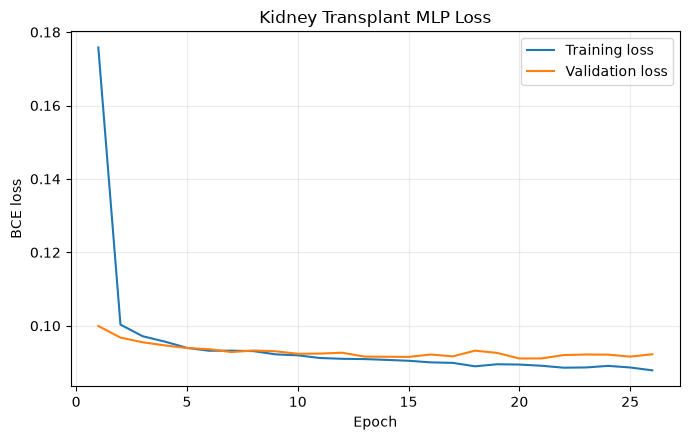

In [32]:
# Plot the selected model's optimization history.
loss_figure, loss_axis = plt.subplots(figsize=(7, 4.5))
loss_axis.plot(training_history["epoch"], training_history["training_loss"], label="Training loss")
loss_axis.plot(training_history["epoch"], training_history["validation_loss"], label="Validation loss")
loss_axis.set(title="Kidney Transplant MLP Loss", xlabel="Epoch", ylabel="BCE loss")
loss_axis.grid(alpha=0.25); loss_axis.legend(); loss_figure.tight_layout()
display(loss_figure); plt.close(loss_figure)

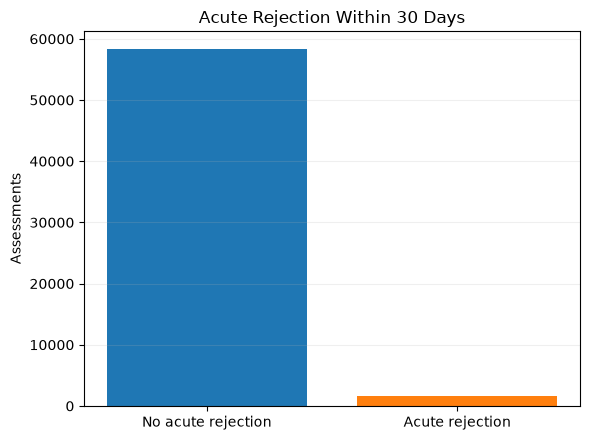

In [33]:
# Show the rare target distribution alongside the no-skill PR-AUC baseline.
target_figure, target_axis = plt.subplots(figsize=(6, 4.5))
target_counts = df_clean[TARGET_COLUMN].value_counts().reindex([0, 1])
target_axis.bar(["No acute rejection", "Acute rejection"], target_counts.values, color=["#1f77b4", "#ff7f0e"])
target_axis.set(title="Acute Rejection Within 30 Days", ylabel="Assessments")
target_axis.grid(axis="y", alpha=0.2); target_figure.tight_layout()
display(target_figure); plt.close(target_figure)

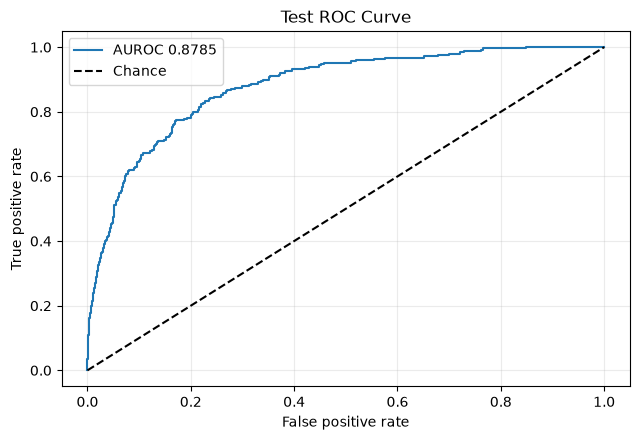

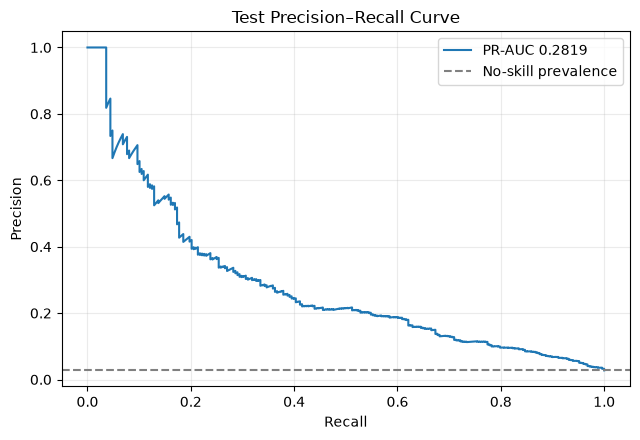

In [34]:
# Plot discrimination in ROC and precision–recall space.
false_positive_rate, true_positive_rate, _ = roc_curve(test_labels, test_probabilities)
pr_precision, pr_recall, _ = precision_recall_curve(test_labels, test_probabilities)
roc_figure, roc_axis = plt.subplots(figsize=(6.5, 4.5))
roc_axis.plot(false_positive_rate, true_positive_rate, label=f"AUROC {test_metrics['auroc']:.4f}")
roc_axis.plot([0, 1], [0, 1], "k--", label="Chance")
roc_axis.set(title="Test ROC Curve", xlabel="False positive rate", ylabel="True positive rate")
roc_axis.grid(alpha=0.25); roc_axis.legend(); roc_figure.tight_layout()
pr_figure, pr_axis = plt.subplots(figsize=(6.5, 4.5))
pr_axis.plot(pr_recall, pr_precision, label=f"PR-AUC {test_metrics['pr_auc']:.4f}")
pr_axis.axhline(test_labels.mean(), color="grey", linestyle="--", label="No-skill prevalence")
pr_axis.set(title="Test Precision–Recall Curve", xlabel="Recall", ylabel="Precision")
pr_axis.grid(alpha=0.25); pr_axis.legend(); pr_figure.tight_layout()
display(roc_figure); display(pr_figure); plt.close(roc_figure); plt.close(pr_figure)

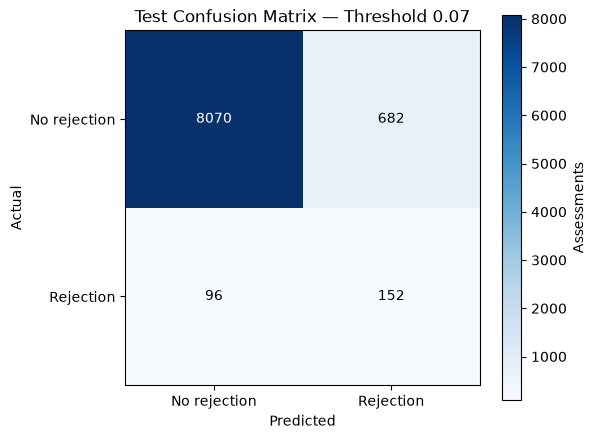

In [35]:
# Display fixed-threshold error counts without treating accuracy as sufficient.
matrix = np.asarray(test_metrics["confusion_matrix"])
confusion_figure, confusion_axis = plt.subplots(figsize=(6, 4.8))
image = confusion_axis.imshow(matrix, cmap="Blues")
confusion_axis.set(title=f"Test Confusion Matrix — Threshold {fixed_baseline_validation_threshold:.2f}",
                   xlabel="Predicted", ylabel="Actual", xticks=[0, 1], yticks=[0, 1],
                   xticklabels=["No rejection", "Rejection"], yticklabels=["No rejection", "Rejection"])
for row in range(2):
    for column in range(2):
        colour = "white" if matrix[row, column] > matrix.max()/2 else "black"
        confusion_axis.text(column, row, matrix[row, column], ha="center", va="center", color=colour)
confusion_figure.colorbar(image, ax=confusion_axis, label="Assessments")
confusion_figure.tight_layout(); display(confusion_figure); plt.close(confusion_figure)

### 7.2 Calibration

Calibration is assessed before the final summary because the modelling objective requires meaningful probabilities, not only ranking. Quantile bins compare mean predicted risk with observed event frequency.

mean_predicted_probability,observed_rejection_rate
0.0002,0.0000
0.0008,0.0011
0.0016,0.0056
0.0030,0.0022
0.0051,0.0044
0.0085,0.0067
0.0141,0.0156
0.0239,0.0267
0.0454,0.0422
0.1698,0.1711


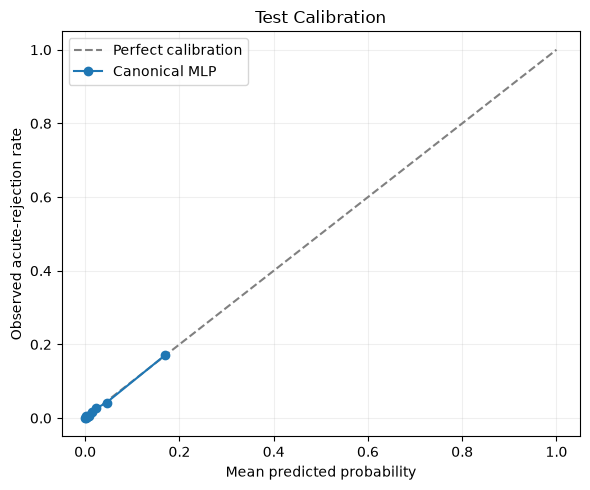

In [36]:
# Compare predicted and observed risk without selecting or recalibrating on test data.
calibration_observed, calibration_predicted = calibration_curve(
    test_labels, test_probabilities, n_bins=10, strategy="quantile"
)
calibration_results = pd.DataFrame({
    "mean_predicted_probability": calibration_predicted,
    "observed_rejection_rate": calibration_observed,
})
calibration_figure, calibration_axis = plt.subplots(figsize=(6, 5))
calibration_axis.plot([0, 1], [0, 1], "--", color="grey", label="Perfect calibration")
calibration_axis.plot(calibration_predicted, calibration_observed, marker="o", label="Canonical MLP")
calibration_axis.set(title="Test Calibration", xlabel="Mean predicted probability",
                     ylabel="Observed acute-rejection rate")
calibration_axis.legend(); calibration_axis.grid(alpha=0.2); calibration_figure.tight_layout()
display(calibration_results.style.hide(axis="index").format(precision=4))
display(calibration_figure); plt.close(calibration_figure)

## 8. Benchmarks and Robustness

### 8.1 Logistic-Regression Benchmark

The benchmark tests whether the MLP adds value beyond a linear decision surface under the same preprocessing and validation-only threshold rule.

In [37]:
# Match the selected imbalance treatment in the linear benchmark.
logistic_model = LogisticRegression(
    max_iter=2_000, random_state=RANDOM_SEED,
    class_weight="balanced" if USE_POSITIVE_WEIGHT else None,
)
logistic_model.fit(X_processed["train"], y.loc[split_indices["train"]])
logistic_validation = logistic_model.predict_proba(X_processed["validation"])[:, 1]
logistic_threshold, _, _ = select_threshold(validation_labels, logistic_validation)
logistic_test = logistic_model.predict_proba(X_processed["test"])[:, 1]
model_comparison = pd.DataFrame([
    {"model": "canonical_mlp", "threshold": fixed_baseline_validation_threshold, **test_metrics},
    {"model": "logistic_regression", "threshold": logistic_threshold,
     **evaluate_predictions(test_labels, logistic_test, logistic_threshold)},
])
display(model_comparison.drop(columns="confusion_matrix").style.hide(axis="index").format(precision=4))

model,threshold,auroc,pr_auc,brier_score,bce,precision,recall,specificity,balanced_accuracy,f1,predicted_positive_count,tn,fp,fn,tp
canonical_mlp,0.0700,0.8785,0.2819,0.0230,0.0931,0.1823,0.6129,0.9221,0.7675,0.2810,834,8070,682,96,152
logistic_regression,0.0700,0.8681,0.2595,0.0233,0.0949,0.1684,0.5968,0.9165,0.7566,0.2626,879,8021,731,100,148


### 8.2 Five-Seed Robustness

Five initializations measure training variability under the chosen loss. Seed 42 remains the sole canonical Original Model used by later unlearning notebooks.

In [38]:
# Reuse the canonical seed-42 run and retrain only the other approved seeds.
robustness_rows = []
for seed in ROBUSTNESS_SEEDS:
    if seed == RANDOM_SEED:
        model, summary = canonical_model, canonical_run["summary"]
        validation_values, test_values = validation_probabilities, test_probabilities
    else:
        model, _, summary = train_model(seed, USE_POSITIVE_WEIGHT)
        validation_values = predict_probabilities(model, tensors["validation"][0])
        test_values = predict_probabilities(model, tensors["test"][0])
    seed_threshold, _, _ = select_threshold(validation_labels, validation_values)
    seed_metrics = evaluate_predictions(test_labels, test_values, seed_threshold)
    robustness_rows.append({
        "seed": seed, "threshold": seed_threshold, "epochs": summary["epochs"],
        **{metric: seed_metrics[metric] for metric in ["auroc", "pr_auc", "precision", "recall", "f1", "balanced_accuracy", "brier_score"]},
    })
robustness = pd.DataFrame(robustness_rows)
robustness_summary = robustness[["auroc", "pr_auc", "precision", "recall", "f1", "balanced_accuracy", "brier_score"]].agg(["mean", "std"]).T.reset_index(names="metric")
display(robustness.style.hide(axis="index").format(precision=4))
display(robustness_summary.style.hide(axis="index").format(precision=4))

seed,threshold,epochs,auroc,pr_auc,precision,recall,f1,balanced_accuracy,brier_score
21,0.0600,16,0.8748,0.2860,0.1651,0.6250,0.2612,0.7677,0.0230
42,0.0700,26,0.8785,0.2819,0.1823,0.6129,0.2810,0.7675,0.0230
84,0.0700,24,0.8760,0.2879,0.1877,0.5685,0.2823,0.7494,0.0229
126,0.0700,27,0.8768,0.2763,0.1820,0.5887,0.2781,0.7569,0.0231
168,0.0700,31,0.8730,0.2884,0.1773,0.6048,0.2742,0.7627,0.0229


metric,mean,std
auroc,0.8758,0.0021
pr_auc,0.2841,0.0050
precision,0.1789,0.0086
recall,0.6000,0.0220
f1,0.2753,0.0085
balanced_accuracy,0.7608,0.0078
brier_score,0.0230,0.0001


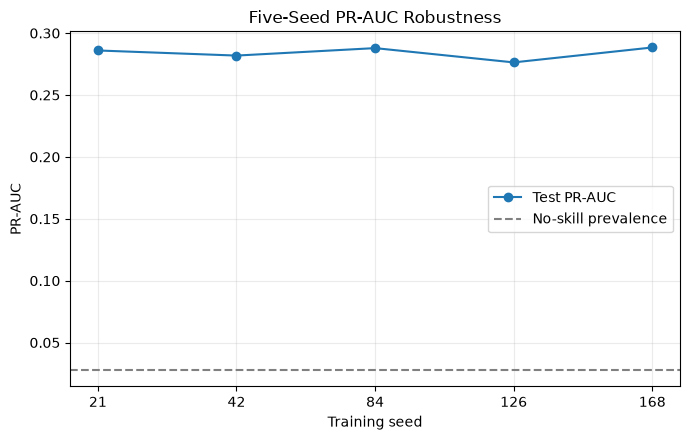

In [39]:
# Plot seed variability relative to the rare-event PR-AUC baseline.
robustness_figure, robustness_axis = plt.subplots(figsize=(7, 4.5))
robustness_axis.plot(robustness["seed"].astype(str), robustness["pr_auc"], marker="o", label="Test PR-AUC")
robustness_axis.axhline(test_labels.mean(), color="grey", linestyle="--", label="No-skill prevalence")
robustness_axis.set(title="Five-Seed PR-AUC Robustness", xlabel="Training seed", ylabel="PR-AUC")
robustness_axis.grid(alpha=0.25); robustness_axis.legend(); robustness_figure.tight_layout()
display(robustness_figure); plt.close(robustness_figure)

## 9. Save Baseline Artifacts

Saving is centralised after all training and evaluation. Exact split arrays, identities, preprocessing, model weights, metrics, histories and plots allow later methods to use one frozen baseline rather than recreating it.

In [40]:
BASELINE_ROOT = RESULTS_ROOT / "baseline"
MODEL_DIR = MODEL_ROOT / "baseline"
for subdirectory in ["configuration", "splits", "metrics", "tables", "figures"]:
    (BASELINE_ROOT / subdirectory).mkdir(parents=True, exist_ok=True)
MODEL_PATH = MODEL_DIR / "kidney_transplant_baseline_mlp.pt"
PREPROCESSOR_PATH = MODEL_DIR / "kidney_transplant_preprocessor.joblib"
SPLIT_INDEX_PATHS = {name: BASELINE_ROOT / f"splits/{name}_indices.npy" for name in split_indices}
SPLIT_ID_PATHS = {name: BASELINE_ROOT / f"splits/{name}_recipient_ids.npy" for name in split_indices}
for name in split_indices:
    np.save(SPLIT_INDEX_PATHS[name], split_indices[name])
    np.save(SPLIT_ID_PATHS[name], split_recipient_ids[name].astype("U"))
joblib.dump(preprocessor, PREPROCESSOR_PATH)

['/Users/niamhhughes/Desktop/Desktop - Niamh’s MacBook Pro/QUB/Research Proj/code/models/KidneyTransplant/baseline/kidney_transplant_preprocessor.joblib']

In [41]:
# Save portable CPU weights with feature, threshold and loss provenance.
cpu_state = {key: value.detach().cpu().clone() for key, value in canonical_model.state_dict().items()}
checkpoint = {
    "state_dict": cpu_state, "input_dim": X_processed["train"].shape[1],
    "architecture": {"hidden_layer_dimensions": list(HIDDEN_LAYER_DIMS), "dropout_probability": DROPOUT_PROBABILITY},
    "feature_columns": FEATURE_COLUMNS, "numeric_columns": NUMERIC_COLUMNS,
    "categorical_columns": CATEGORICAL_FEATURES, "processed_feature_names": processed_feature_names,
    "excluded_audit_columns": EXCLUDED_AUDIT_COLUMNS, "target_column": TARGET_COLUMN,
    "seed": RANDOM_SEED, "selected_loss": SELECTED_LOSS,
    "training_positive_weight": TRAIN_POS_WEIGHT if USE_POSITIVE_WEIGHT else None,
    "fixed_baseline_validation_threshold": fixed_baseline_validation_threshold,
    "threshold_selection_rule": THRESHOLD_SELECTION_REASON,
    "training_configuration": {"batch_size": BATCH_SIZE, "learning_rate": LEARNING_RATE,
        "weight_decay": WEIGHT_DECAY, "maximum_epochs": MAX_EPOCHS,
        "early_stopping_patience": EARLY_STOPPING_PATIENCE,
        "early_stopping_min_delta": EARLY_STOPPING_MIN_DELTA},
    "raw_dataset_hash": RAW_DATA_HASH, "processed_dataset_hash": PROCESSED_DATA_HASH,
}
torch.save(checkpoint, MODEL_PATH)

In [42]:
# Persist all established numeric results and figure outputs.
TABLES = {
    "metrics": (metrics_table, BASELINE_ROOT / "metrics/baseline_metrics.csv"),
    "training_history": (training_history, BASELINE_ROOT / "tables/training_history.csv"),
    "loss_comparison": (loss_comparison, BASELINE_ROOT / "tables/loss_comparison.csv"),
    "threshold_sweep": (threshold_sweep, BASELINE_ROOT / "tables/threshold_validation_sweep.csv"),
    "model_comparison": (model_comparison, BASELINE_ROOT / "tables/model_comparison.csv"),
    "robustness": (robustness, BASELINE_ROOT / "tables/five_seed_robustness.csv"),
    "robustness_summary": (robustness_summary, BASELINE_ROOT / "tables/five_seed_robustness_summary.csv"),
    "calibration": (calibration_results, BASELINE_ROOT / "tables/calibration_results.csv"),
    "split_summary": (split_summary, BASELINE_ROOT / "tables/split_summary.csv"),
    "hospital_split": (hospital_split, BASELINE_ROOT / "tables/hospital_split.csv"),
}
for frame, path in TABLES.values():
    frame.to_csv(path, index=False)
FIGURES = {"target_distribution": target_figure, "loss_curve": loss_figure, "roc_curve": roc_figure,
           "precision_recall_curve": pr_figure, "confusion_matrix": confusion_figure,
           "calibration": calibration_figure, "robustness": robustness_figure}
FIGURE_PATHS = {name: BASELINE_ROOT / f"figures/{name}.png" for name in FIGURES}
for name, figure in FIGURES.items():
    figure.savefig(FIGURE_PATHS[name], dpi=300, bbox_inches="tight")

In [43]:
# Build a manifest with split hashes and all reusable baseline configuration.
split_artifacts = {name: {
    "index_path": str(SPLIT_INDEX_PATHS[name].relative_to(CODE_ROOT)),
    "index_sha256": sha256(SPLIT_INDEX_PATHS[name]),
    "recipient_id_path": str(SPLIT_ID_PATHS[name].relative_to(CODE_ROOT)),
    "recipient_id_sha256": sha256(SPLIT_ID_PATHS[name]),
    "recipient_count": len(split_recipient_ids[name]), "row_count": len(split_indices[name]),
} for name in split_indices}
manifest = {
    "dataset_path": str(RAW_DATA_PATH.relative_to(CODE_ROOT)), "dataset_hash": RAW_DATA_HASH,
    "processed_dataset_path": str(PROCESSED_DATA_PATH.relative_to(CODE_ROOT)),
    "processed_dataset_hash": PROCESSED_DATA_HASH,
    "dataset_description": "Entirely synthetic longitudinal post-transplant assessments; six rows per recipient.",
    "target": TARGET_COLUMN, "feature_list": FEATURE_COLUMNS,
    "excluded_audit_fields": EXCLUDED_AUDIT_COLUMNS,
    "split_strategy": "recipient-grouped hospital/consent/outcome-aware deterministic 70/15/15 split",
    "group_key": "recipient_id", "seed": RANDOM_SEED, "robustness_seeds": ROBUSTNESS_SEEDS,
    "split_artifacts": split_artifacts,
    "fixed_baseline_validation_threshold": fixed_baseline_validation_threshold,
    "loss_choice": SELECTED_LOSS, "preprocessing_policy": "fit_on_training_rows_only",
    "model_path": str(MODEL_PATH.relative_to(CODE_ROOT)), "model_hash": sha256(MODEL_PATH),
    "preprocessor_path": str(PREPROCESSOR_PATH.relative_to(CODE_ROOT)),
    "preprocessor_hash": sha256(PREPROCESSOR_PATH),
    "runtime_environment": {"python": platform.python_version(), "numpy": np.__version__,
        "pandas": pd.__version__, "scikit_learn": sklearn.__version__,
        "pytorch": torch.__version__, "device": str(DEVICE)},
    "artifact_hashes": {str(path.relative_to(CODE_ROOT)): sha256(path)
        for _, path in TABLES.values() for path in [path]},
}
MANIFEST_PATH = BASELINE_ROOT / "configuration/baseline_manifest.json"
MANIFEST_PATH.write_text(json.dumps(manifest, indent=2))

5268

## 10. Reload and Verification

Every saved artifact is reloaded and compared with its executed in-memory source. This catches serialization, path and schema failures before deletion notebooks depend on the baseline.

In [44]:
def assert_saved_table(path: Path, expected: pd.DataFrame) -> None:
    saved = pd.read_csv(path)
    assert saved.columns.tolist() == expected.columns.tolist() and len(saved) == len(expected)
    for column in expected.columns:
        if is_numeric_dtype(expected[column]):
            assert np.allclose(saved[column], expected[column], equal_nan=True)


for frame, path in TABLES.values():
    assert_saved_table(path, frame)
saved_preprocessor = joblib.load(PREPROCESSOR_PATH)
saved_checkpoint = torch.load(MODEL_PATH, map_location="cpu", weights_only=False)
assert saved_checkpoint["feature_columns"] == FEATURE_COLUMNS
assert saved_checkpoint["fixed_baseline_validation_threshold"] == fixed_baseline_validation_threshold
assert saved_preprocessor.get_feature_names_out().tolist() == processed_feature_names

In [45]:
# Rebuild the portable model and reproduce a test prediction sample.
reloaded_model = KidneyTransplantMLP(saved_checkpoint["input_dim"])
reloaded_model.load_state_dict(saved_checkpoint["state_dict"])
reloaded_model = reloaded_model.to(DEVICE).eval()
reloaded_probabilities = predict_probabilities(reloaded_model, tensors["test"][0])
assert np.allclose(reloaded_probabilities, test_probabilities, rtol=1e-6, atol=1e-7)
reloaded_metrics = evaluate_predictions(test_labels, reloaded_probabilities, fixed_baseline_validation_threshold)
for metric in ["auroc", "pr_auc", "brier_score", "bce", "f1", "balanced_accuracy"]:
    assert np.isclose(reloaded_metrics[metric], test_metrics[metric], rtol=1e-6)
for name in split_indices:
    assert np.array_equal(np.load(SPLIT_INDEX_PATHS[name]), split_indices[name])
    assert np.array_equal(np.load(SPLIT_ID_PATHS[name]), split_recipient_ids[name].astype("U"))
assert json.loads(MANIFEST_PATH.read_text()) == manifest
assert all(path.is_file() for path in [MODEL_PATH, PREPROCESSOR_PATH, MANIFEST_PATH, *FIGURE_PATHS.values()])
print("Baseline model, preprocessing, splits, metrics and figures reloaded successfully.")

Baseline model, preprocessing, splits, metrics and figures reloaded successfully.


## 11. Final Summary

In [46]:
# Generate the final interpretation from executed metrics rather than hardcoded values.
seed_pr_mean = robustness["pr_auc"].mean()
seed_pr_std = robustness["pr_auc"].std()
seed_recall_mean = robustness["recall"].mean()
seed_recall_std = robustness["recall"].std()
display(Markdown(
    f"- **Rare target:** overall acute-rejection prevalence is {y.mean():.2%}; the test no-skill PR-AUC is {test_labels.mean():.4f}.\n"
    f"- **Rare-event performance:** test PR-AUC is {test_metrics['pr_auc']:.4f}; test AUROC is supplementary at {test_metrics['auroc']:.4f}.\n"
    f"- **Calibration:** Brier score is {test_metrics['brier_score']:.4f} and BCE is {test_metrics['bce']:.4f}.\n"
    f"- **Frozen operating point:** threshold {fixed_baseline_validation_threshold:.2f} follows the validation recall-at-least-0.60 rule; "
    f"test recall is {test_metrics['recall']:.4f}, precision is {test_metrics['precision']:.4f}, "
    f"with {test_metrics['tp']} true positives and {test_metrics['fn']} false negatives.\n"
    f"- **Robustness:** five-seed PR-AUC is {seed_pr_mean:.4f} ± {seed_pr_std:.4f}; recall is {seed_recall_mean:.4f} ± {seed_recall_std:.4f}.\n"
    "- **Limitations:** the rare positive class makes precision, recall and positive-class conclusions uncertain; data are synthetic, with one architecture and an experimental—not clinical—threshold."
))

- **Rare target:** overall acute-rejection prevalence is 2.81%; the test no-skill PR-AUC is 0.0276.
- **Rare-event performance:** test PR-AUC is 0.2819; test AUROC is supplementary at 0.8785.
- **Calibration:** Brier score is 0.0230 and BCE is 0.0931.
- **Frozen operating point:** threshold 0.07 follows the validation recall-at-least-0.60 rule; test recall is 0.6129, precision is 0.1823, with 152 true positives and 96 false negatives.
- **Robustness:** five-seed PR-AUC is 0.2841 ± 0.0050; recall is 0.6000 ± 0.0220.
- **Limitations:** the rare positive class makes precision, recall and positive-class conclusions uncertain; data are synthetic, with one architecture and an experimental—not clinical—threshold.